In [1]:
#April 22, 2026
#Charlotte Meyer
#Data Seminar
#This code is meant to use statsmodels to create a logistic regression

In [2]:
#importing packages
import statsmodels.api
import pandas as pd
import statsmodels.formula.api as smf
#from statsmodels.formula.api import ols
import numpy as np
#import statsmodels.api as sm
#from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.metrics import classification_report

In [3]:
#reading in the data 
cejst = pd.read_csv("cejst_logistic_regression.csv", index_col=0, low_memory=False)

#setting pandas columns so I can see all of them
pd.set_option('display.max_columns', None)

In [4]:
# Define predictor variables
predictors = ['perc_white', 'perc_poverty', 'pm_air', 'perc_unemployment', 
              'hazard_waste_prox', 'life_expectancy', 'perc_hispanic', 
              'perc_elderly', 'perc_children', 'perc_disadvantaged', 
              'population', 'loss_rate', 'flood_risk', 'energy_burden', 
              'diesel_exposure', 'traffic_prox', 'travel_barriers', 
              'housing_burden', 'house_value', 'pavement_cropland', 
              'no_plumbing', 'superfund_prox', 
              'asthma', 'diabetes', 'heart_disease', 'household_income_compared', 
              'linguistic_isolation', 'no_hs_degree']

print(cejst[predictors].isnull().sum())
#removing wastewater_discharge from predictors because it has 20,000 NA's

perc_white                    744
perc_poverty                  158
pm_air                       1875
perc_unemployment             973
hazard_waste_prox             158
life_expectancy              6986
perc_hispanic                 744
perc_elderly                  861
perc_children                 861
perc_disadvantaged              0
population                     28
loss_rate                    1604
flood_risk                    796
energy_burden                1054
diesel_exposure               739
traffic_prox                 2834
travel_barriers              1801
housing_burden               1158
house_value                  2201
pavement_cropland            1595
no_plumbing                  1158
superfund_prox                158
asthma                       3821
diabetes                     3821
heart_disease                3821
household_income_compared    5021
linguistic_isolation         1932
no_hs_degree                  879
dtype: int64


In [5]:
#dropping NA's; code is from Claude


#dropping all rows with NaN in predictor columns
cejst = cejst.dropna(subset=predictors)

#verify they match
print(f"X shape: {cejst[predictors].shape}, y shape: {cejst["has_datacenter"].shape}")
#verify no na's
print(cejst[predictors].isnull().sum())

X shape: (59078, 28), y shape: (59078,)
perc_white                   0
perc_poverty                 0
pm_air                       0
perc_unemployment            0
hazard_waste_prox            0
life_expectancy              0
perc_hispanic                0
perc_elderly                 0
perc_children                0
perc_disadvantaged           0
population                   0
loss_rate                    0
flood_risk                   0
energy_burden                0
diesel_exposure              0
traffic_prox                 0
travel_barriers              0
housing_burden               0
house_value                  0
pavement_cropland            0
no_plumbing                  0
superfund_prox               0
asthma                       0
diabetes                     0
heart_disease                0
household_income_compared    0
linguistic_isolation         0
no_hs_degree                 0
dtype: int64


In [6]:
#making a function that will split columns into bins for fixed effects

def split_into_bins(fixed_effect_column):

    #cut into 11 bins (arbitrary)
    #using cut, NOT qcut
    cejst[fixed_effect_column + "_bin"] = pd.cut(cejst[fixed_effect_column], 11, labels=range(1,12))
    
    #creating dummies, prefix adds column in front of bin name
    dummies = pd.get_dummies(cejst[fixed_effect_column + "_bin"])#, prefix=fixed_column_effect)
    
    #removing middle dummy
    dummies = dummies[[i for i in dummies.columns if i != 6]]
    
    #renaming dummies
    dummies.columns = [fixed_effect_column + "_" + str(i) for i in dummies.columns ]
    
    #combining existing columns with cejst
#    dummies[fixed_effect_column] = cejst[fixed_effect_column]
#    dummies['has_datacenter'] = cejst['has_datacenter']

    #drop na
    dummies = dummies.dropna()
    
    #viewing bins
    return dummies
#    return cejst.groupby('bin')[[fixed_effect_column, 'has_datacenter']].mean() #this shows the bins; will show bin 6

In [7]:
linguistic_isolation_dummies = split_into_bins("linguistic_isolation")
linguistic_isolation_dummies

#cejst = cejst.copy()
cejst = pd.concat([cejst, linguistic_isolation_dummies], axis=1)

/var/folders/sl/dyq7sj0x2_z0dr2x82v1ln_80000gn/T/ipykernel_39381/23027534.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cejst[fixed_effect_column + "_bin"] = pd.cut(cejst[fixed_effect_column], 11, labels=range(1,12))


In [8]:
perc_poverty_dummies = split_into_bins("perc_poverty")
perc_poverty_dummies

cejst = pd.concat([cejst, perc_poverty_dummies], axis=1)

/var/folders/sl/dyq7sj0x2_z0dr2x82v1ln_80000gn/T/ipykernel_39381/23027534.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  cejst[fixed_effect_column + "_bin"] = pd.cut(cejst[fixed_effect_column], 11, labels=range(1,12))


In [9]:
cejst

,GEOID,County Name,State,perc_black,perc_native_american,perc_asian,perc_hawaiin_pacific,perc_mixed_race,perc_white,perc_hispanic,Percent other races,perc_children,Percent age 10 to 64,perc_elderly,Total threshold criteria exceeded,Total categories exceeded,Identified as disadvantaged without considering neighbors,Identified as disadvantaged based on neighbors and relaxed low income threshold only,Identified as disadvantaged due to tribal overlap,Identified as disadvantaged,perc_disadvantaged,Share of neighbors that are identified as disadvantaged,Identified as disadvantaged in v1.0,Identified as disadvantaged solely due to status in v1.0 (grandfathered),population,Interpolated number of off-campus students in poverty,Adjusted percent of individuals below 200% Federal Poverty Line (percentile),perc_poverty,Is low income?,Income data has been estimated based on geographic neighbor income,Greater than or equal to the 90th percentile for expected agriculture loss rate and is low income?,Expected agricultural loss rate (Natural Hazards Risk Index) (percentile),Expected agricultural loss rate (Natural Hazards Risk Index),Greater than or equal to the 90th percentile for expected building loss rate and is low income?,Expected building loss rate (Natural Hazards Risk Index) (percentile),Expected building loss rate (Natural Hazards Risk Index),Greater than or equal to the 90th percentile for expected population loss rate and is low income?,Expected population loss rate (Natural Hazards Risk Index) (percentile),loss_rate,Share of properties at risk of flood in 30 years (percentile),flood_risk,Greater than or equal to the 90th percentile for share of properties at risk of flood in 30 years,Greater than or equal to the 90th percentile for share of properties at risk of flood in 30 years and is low income?,Share of properties at risk of fire in 30 years (percentile),Share of properties at risk of fire in 30 years,Greater than or equal to the 90th percentile for share of properties at risk of fire in 30 years,Greater than or equal to the 90th percentile for share of properties at risk of fire in 30 years and is low income?,Greater than or equal to the 90th percentile for energy burden and is low income?,Energy burden (percentile),energy_burden,Greater than or equal to the 90th percentile for PM2.5 exposure and is low income?,PM2.5 in the air (percentile),pm_air,Greater than or equal to the 90th percentile for diesel particulate matter and is low income?,Diesel particulate matter exposure (percentile),diesel_exposure,Greater than or equal to the 90th percentile for traffic proximity and is low income?,Traffic proximity and volume (percentile),traffic_prox,Greater than or equal to the 90th percentile for DOT transit barriers and is low income?,travel_barriers,Greater than or equal to the 90th percentile for housing burden and is low income?,Housing burden (percent) (percentile),housing_burden,"Greater than or equal to the 90th percentile for lead paint, the median house value is less than 90th percentile and is low income?",Percent pre-1960s housing (lead paint indicator) (percentile),Percent pre-1960s housing (lead paint indicator),Median value ($) of owner-occupied housing units (percentile),house_value,Greater than or equal to the 90th percentile for share of the tract's land area that is covered by impervious surface or cropland as a percent and is low income?,Greater than or equal to the 90th percentile for share of the tract's land area that is covered by impervious surface or cropland as a percent,Share of the tract's land area that is covered by impervious surface or cropland as a percent,pavement_cropland,Does the tract have at least 35 acres in it?,Tract experienced historic underinvestment and remains low income,Tract experienced historic underinvestment,no_plumbing,Share of homes with no kitchen or indoor plumbing (percent),Greater than or equal to the 90th percentile for proximity to hazardous waste facilities and is low income?,

In [10]:
#splitting train and test split
#this code is from Claude

#split the dataframe
train_df, test_df = train_test_split(cejst, test_size=0.25, random_state=29)

#how many data centers in test split?
pd.DataFrame(test_df["has_datacenter"]).value_counts()


#fit on training data
#formula = 'has_datacenter ~ perc_poverty + income + education'
#model = smf.logit(formula, data=train_df)
#result = model.fit()

# Evaluate on test data
#test_predictions = result.predict(test_df)

# Calculate accuracy or other metrics
#from sklearn.metrics import accuracy_score, confusion_matrix
#y_pred = (test_predictions > 0.5).astype(int)
#accuracy = accuracy_score(test_df['has_datacenter'], y_pred)
#print(f"Test accuracy: {accuracy}")

has_datacenter
0                 14688
1                    82
Name: count, dtype: int64

In [11]:
# "'has_datacenter ~ ' + ' + '.join(predictors)"
#logistic regression model with fixed effects

#list of dummy dataframes
dummy_list = [linguistic_isolation_dummies, perc_poverty_dummies]

#making list of dummy columns that predict a data center ??
for new_dummy in dummy_list:
    #dummies that predict data center
    dummy_predictors = [i for i in new_dummy.columns if i != 'has_datacenter']

#combining regular predictor columns with dummy predictor columns
all_predictors = predictors + dummy_predictors

#fixed effects model
#fit on training data
my_fixed_effects_model = statsmodels.formula.api.logit('has_datacenter ~ ' + ' + '.join(all_predictors), 
    data=train_df, subset=None, drop_cols=None).fit(disp=False) #, *args, **kwargs


# Evaluate on test data
test_predictions = my_fixed_effects_model.predict(test_df)

my_fixed_effects_model.summary()

/Users/charlottemeyer/anaconda3/envs/.da_401/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         has_datacenter   No. Observations:                44308
Model:                          Logit   Df Residuals:                    44269
Method:                           MLE   Df Model:                           38
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:                 0.05142
Time:                        23:25:53   Log-Likelihood:                -1335.4
converged:                      False   LL-Null:                       -1407.8
Covariance Type:            nonrobust   LLR p-value:                 2.258e-14
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     2.0280      2.585      0.785      0.433      -3.038       7.094
perc_poverty_1[T.True]       -1.5474      1.202     -1.287      0.198      -3.903       0.809
perc_poverty_2[T.True]       -1.4566      1.014     -1.436      0.151      -3.445       0.532
perc_poverty_3[T.True]       -1.1497      0.798     -1.441      0.150      -2.713       0.414
perc_poverty_4[T.True]       -0.6159      0.584     -1.054      0.292      -1.761       0.529
perc_poverty_5[T.True]       -0.7901      0.415     -1.905      0.057      -1.603       0.023
perc_poverty_7[T.True]        0.8753      0.424      2.062      0.039       0.043       1.707
perc_poverty_8[T.True]        0.6688      0.746      0.897      0.370      -0.793       2.131
perc_poverty_9[T.True]        2.2787      0.925      2.465      0.014       0.467       4.091
perc_poverty_10[T.True]     -35.4033   2.12e+08  -1.67e-07      1.000   -4.15e+08    4.15e+08
perc_poverty_11[T.True]      -4.1721    235.210     -0.018      0.986    -465.175     456.830
perc_white                   -0.9515      0.571     -1.667      0.096      -2.070       0.167
perc_poverty                 -5.1957      2.923     -1.777      0.075     -10.925       0.533
pm_air                       -0.0542      0.047     -1.155      0.248      -0.146       0.038
perc_unemployment             0.0135      0.024      0.565      0.572      -0.033       0.060
hazard_waste_prox             0.0140      0.020      0.701      0.483      -0.025       0.053
life_expectancy              -0.0047      0.026     -0.185      0.853      -0.055       0.045
perc_hispanic                 0.0107      0.593      0.018      0.986      -1.151       1.172
perc_elderly                 -2.6557      1.992     -1.333      0.182      -6.560       1.248
perc_children                -1.1298      2.058     -0.549      0.583      -5.163       2.904
perc_disadvantaged            0.0018      0.003      0.627      0.530      -0.004       0.007
population                -8.762e-05    3.6e-05     -2.437      0.015      -0.000   -1.71e-05
loss_rate                    23.1856     58.495      0.396      0.692     -91.462     137.833
flood_risk                   -0.0059      0.005     -1.139      0.255      -0.016       0.004
energy_burden                -0.4593      0.089     -5.155      0.000      -0.634      -0.285
diesel_exposure              -0.1514      0.414     -0.366      0.715      -0.963       0.660
traffic_prox               4.114e-05   3.55e-05      1.157      0.247   -2.85e-05       0.000
travel_barriers               0.0009      0.003      0.303      0.762      -0.005       0.007
housing_burden               -0.0213      0.011     -1.897      0.058      -0.043       0.001
house_value               -1.651e-06    5.1e-07     -3.239      0.001   -2.65e-06   -6.52e-07
pavement_cropland             0.0050      0.003      1.476      0.140      -0.002       0.012
no_plumbing                   0.1144      0.2

In [12]:
#looking at how good the model is
#the following chunks of code were originally in my scikitlearn logistic regression ipynb. 
#Because that is slightly different (splits into X and y, which this code does not), I asked Claude to adapt it for this model.

# calculating probability that each tract contains a data center
y_pred_proba = my_fixed_effects_model.predict(test_df)

# array of whether or not the model predicted that each tract would contain a data center
y_pred = (y_pred_proba > 0.005).astype(int)

# checking the data type of y_test
# a pandas series is a one-dimensional array with axis labels.
y_test = test_df['has_datacenter']
type(y_test)

pandas.Series

In [13]:
# results dataframe
# prob_0 is probability not a data center
# prob_1 is probability a data center
# also creating bins (below)
df_results = pd.DataFrame()
df_results['prediction'] = y_pred
df_results['prob_0'] = 1 - y_pred_proba
df_results['prob_1'] = y_pred_proba
df_results['label'] = y_test.to_list()
df_results['correct'] = df_results['prediction'] == df_results['label']
df_results['p1_bins'] = pd.qcut(df_results['prob_1'], q=30, labels=range(1, 31))
df_results.sort_values(by='prob_1', ascending=False).head(10)

,prediction,prob_0,prob_1,label,correct,p1_bins
32351,1,0.899632,0.100368,0,False,30
32353,1,0.927803,0.072197,0,False,30
13991,1,0.935311,0.064689,0,False,30
13983,1,0.939870,0.060130,0,False,30
13989,1,0.942711,0.057289,0,False,30
32343,1,0.946600,0.053400,0,False,30
13926,1,0.952687,0.047313,0,False,30
10744,1,0.954614,0.045386,0,False,30
36125,1,0.956553,0.043447,0,False,30
57756,1,0.956790,0.043210,0,False,30


In [14]:
# the tracts are sorted into 30 bins.
#they are sorted into these bins based on the probability that the tract contains a data center
#tracts in bin 1 are very unlikely to contain a data center
#tracts in bin 30 are very likely to contain a data center
#here we look at the percentage of tracts in each bin that were correctly identified by the model as either having or not having a data center
#we can see that the first 15 bins, or the half of tracts that are least likely to contain data centers, are 99% identified correctly
#then a sudden jump where the half of tracts that are more likely to contain a data center are identified correctly >1% of the time
#this makes sense with the fact that we have an acurracy only slightly over 50%

df_results.groupby('p1_bins')[['correct']].mean()

,correct
p1_bins,
1,1.000000
2,1.000000
3,0.997967
4,0.995943
5,1.000000
6,1.000000
7,0.993915
8,0.997967
9,1.000000


In [15]:
# looking at the tracts that DO contain data centers
df_results.loc[df_results['label'] == 1].sort_values(by='prob_1', ascending=False).head(10)

,prediction,prob_0,prob_1,label,correct,p1_bins
9413,1,0.966221,0.033779,1,True,30
39649,1,0.974553,0.025447,1,True,30
63162,1,0.976218,0.023782,1,True,30
2118,1,0.978314,0.021686,1,True,30
31933,1,0.978684,0.021316,1,True,30
42802,1,0.982040,0.017960,1,True,30
21036,1,0.982134,0.017866,1,True,30
35542,1,0.982753,0.017247,1,True,30
11795,1,0.982802,0.017198,1,True,30
67104,1,0.983108,0.016892,1,True,30


In [16]:
# looking at tracts with data centers that weren't predicted to have data centers
# still cuts off at 50%
df_results.loc[(df_results['label'] == 1) & (df_results['correct'] == False)].sort_values(by='prob_1', ascending=False).head(10)

,prediction,prob_0,prob_1,label,correct,p1_bins
39761,0,0.995002,0.004998,1,False,20
50090,0,0.995181,0.004819,1,False,19
70857,0,0.995363,0.004637,1,False,19
12933,0,0.995416,0.004584,1,False,19
65405,0,0.995918,0.004082,1,False,17
1960,0,0.995987,0.004013,1,False,17
48434,0,0.996026,0.003974,1,False,17
69633,0,0.996153,0.003847,1,False,16
66628,0,0.996161,0.003839,1,False,16
54945,0,0.996186,0.003814,1,False,16


In [17]:
# how many does the model choose correctly?
df_results['correct'].value_counts()

correct
True     9525
False    5245
Name: count, dtype: int64

In [18]:
# new dataframe
# how much does each feature column affect the model?
# "score" for each feature column is the coefficient tells us how it is attributing to whether a tract is identified as a data center or not
# new cell here
df_coef = pd.DataFrame()
df_coef['feature'] = my_fixed_effects_model.params.index
df_coef['score'] = my_fixed_effects_model.params.values
df_coef
# df_coef.sort_values(by='score', ascending=False)

,feature,score
0,Intercept,2.027987
1,perc_poverty_1[T.True],-1.547399
2,perc_poverty_2[T.True],-1.456629
3,perc_poverty_3[T.True],-1.149727
4,perc_poverty_4[T.True],-0.615896
5,perc_poverty_5[T.True],-0.790054
6,perc_poverty_7[T.True],0.875307
7,perc_poverty_8[T.True],0.668769
8,perc_poverty_9[T.True],2.278746
9,perc_poverty_10[T.True],-35.403286


In [19]:
# calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"accuracy: {round(accuracy,2)}", float(df_results['correct'].sum()/df_results.shape[0] * 100))

accuracy: 0.64 64.48882870683819


In [20]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[9476, 5212],
       [  33,   49]])

In [21]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.65      0.78     14688
           1       0.01      0.60      0.02        82

    accuracy                           0.64     14770
   macro avg       0.50      0.62      0.40     14770
weighted avg       0.99      0.64      0.78     14770



In [22]:
# calculate recall
# recall: out of every tract that actually has data centers, how many are predicted to have data centers?
recall = recall_score(y_test, y_pred)
f"Recall: {round(recall,2)}"

'Recall: 0.6'

In [23]:
# calculate f1 score
# f1 score combines precision and recall into one metric
# f1 score = 2 _(p_r / p+r)
# f1 score is only high when both precision and recall are high
f1 = f1_score(y_test, y_pred)
f"f1 score: {round(f1,2)}"

'f1 score: 0.02'

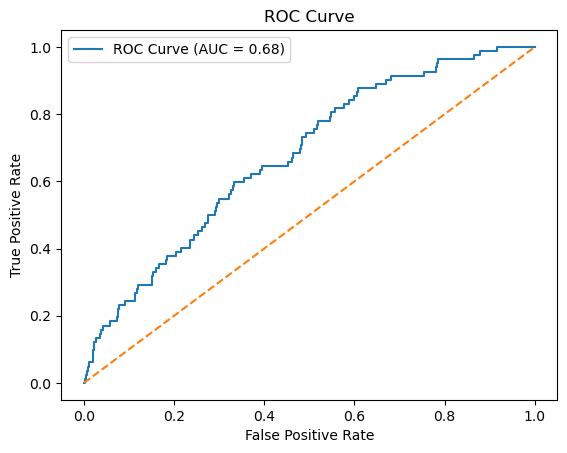

In [24]:
# ROC curve
# shows us the rate of true positive selections vs. false positive selections
# aka recall for class 1 vs. recall for class 0
# the sooner this line reaches 1.0, the better
# the closer this line is to the orange line, the worse -- orange is random selection
y_prob = y_pred_proba
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [25]:
#list of columns that had low p-values in logit model
feature_columns_significant = ["perc_poverty",
                               "perc_hispanic",
                               "perc_elderly",
                               "population",
                               "loss_rate",
                               "travel_barriers",
                               "house_value",
                               "risk_facilities_prox",
                               "leaky_storage_tanks",
                               "asthma"]

new_significant = ["population", 
                   "energy_burden",
                   "risk_facilities_prox",
                   "linguistic_isolation"]
                   

In [26]:
#splittling into testing and training
#X_train, X_test, y_train, y_test = train_test_split(
#    X, y, test_size=0.25, random_state=26
#)

In [27]:
#still need this for the multicollinearity test
X = cejst[predictors]
y = cejst["has_datacenter"]

#dropping all rows with NaN in X columns
X = X.dropna()
#Keep y aligned with X
y = y.loc[X.index]  

# Verify they match
print(f"X shape: {X.shape}, y shape: {y.shape}")
#verify no na's
print(X.isnull().sum())

X shape: (59078, 28), y shape: (59078,)
perc_white                   0
perc_poverty                 0
pm_air                       0
perc_unemployment            0
hazard_waste_prox            0
life_expectancy              0
perc_hispanic                0
perc_elderly                 0
perc_children                0
perc_disadvantaged           0
population                   0
loss_rate                    0
flood_risk                   0
energy_burden                0
diesel_exposure              0
traffic_prox                 0
travel_barriers              0
housing_burden               0
house_value                  0
pavement_cropland            0
no_plumbing                  0
superfund_prox               0
asthma                       0
diabetes                     0
heart_disease                0
household_income_compared    0
linguistic_isolation         0
no_hs_degree                 0
dtype: int64


In [28]:
#code adapted from https://www.statology.org/how-to-test-for-multicollinearity-with-statsmodels/
#testing for multicollinearity

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Compute VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data)

                      feature         VIF
0                  perc_white   28.306099
1                perc_poverty   36.799589
2                      pm_air   33.984501
3           perc_unemployment    4.468159
4           hazard_waste_prox    2.869737
5             life_expectancy  169.153638
6               perc_hispanic    5.166315
7                perc_elderly   20.266485
8               perc_children   15.103475
9          perc_disadvantaged    4.392691
10                 population    6.210092
11                  loss_rate    1.216665
12                 flood_risk    1.644375
13              energy_burden   10.629757
14            diesel_exposure    6.446378
15               traffic_prox    1.722776
16            travel_barriers    6.186916
17             housing_burden   18.805930
18                house_value    5.079448
19          pavement_cropland    7.096850
20                no_plumbing    4.452115
21             superfund_prox    1.318499
22                     asthma   11

In [29]:
#diagnostics from Claude to figure out if i have class imbalance issue

# Check your class balance
print("Training set distribution:")
print(train_df['has_datacenter'].value_counts())
print(train_df['has_datacenter'].value_counts(normalize=True))

# Check what your model is predicting
print("\nPredictions distribution:")
print(df_results['prediction'].value_counts())
print(f"\nProbability range: {y_pred_proba.min():.4f} to {y_pred_proba.max():.4f}")

Training set distribution:
has_datacenter
0    44084
1      224
Name: count, dtype: int64
has_datacenter
0    0.994944
1    0.005056
Name: proportion, dtype: float64

Predictions distribution:
prediction
0    9509
1    5261
Name: count, dtype: int64

Probability range: 0.0000 to 0.1004


In [30]:
#figuring out which threshold to use for y_pred_proba
#code adapted from Claude

thresholds_to_try = [0.001, 0.005, 0.01, 0.05]
for threshold in thresholds_to_try:
    y_pred_temp = (y_pred_proba > threshold).astype(int)
    recall_temp = recall_score(y_test, y_pred_temp)
    precision_temp = precision_score(y_test, y_pred_temp)
    print(f"Threshold {threshold}: Recall={recall_temp:.2f}, Precision={precision_temp:.2f}")

Threshold 0.001: Recall=1.00, Precision=0.01
Threshold 0.005: Recall=0.60, Precision=0.01
Threshold 0.01: Recall=0.24, Precision=0.01
Threshold 0.05: Recall=0.00, Precision=0.00
